Total files: 281


I0000 00:00:1774465820.892892      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Training V-Net...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1774465831.375782     195 service.cc:152] XLA service 0x7b8504211280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774465831.375838     195 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774465832.950775     195 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/448 ━━━━━━━━━━━━━━━━━━━━ 1:58:00 16s/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.7639

I0000 00:00:1774465839.742343     195 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


448/448 ━━━━━━━━━━━━━━━━━━━━ 282s 595ms/step - accuracy: 0.6946 - auc: 0.8334 - loss: 0.5299 - val_accuracy: 0.8509 - val_auc: 0.8797 - val_loss: 0.3561
Epoch 2/5
448/448 ━━━━━━━━━━━━━━━━━━━━ 63s 141ms/step - accuracy: 0.9087 - auc: 0.9233 - loss: 0.2610 - val_accuracy: 0.8421 - val_auc: 0.8735 - val_loss: 0.3548
Epoch 3/5
448/448 ━━━━━━━━━━━━━━━━━━━━ 64s 143ms/step - accuracy: 0.9033 - auc: 0.9429 - loss: 0.2382 - val_accuracy: 0.8421 - val_auc: 0.8766 - val_loss: 0.3528
Epoch 4/5
448/448 ━━━━━━━━━━━━━━━━━━━━ 62s 138ms/step - accuracy: 0.9298 - auc: 0.9401 - loss: 0.2412 - val_accuracy: 0.8684 - val_auc: 0.8907 - val_loss: 0.3273
Epoch 5/5
448/448 ━━━━━━━━━━━━━━━━━━━━ 61s 137ms/step - accuracy: 0.9200 - auc: 0.9300 - loss: 0.2724 - val_accuracy: 0.8596 - val_auc: 0.8987 - val_loss: 0.3210


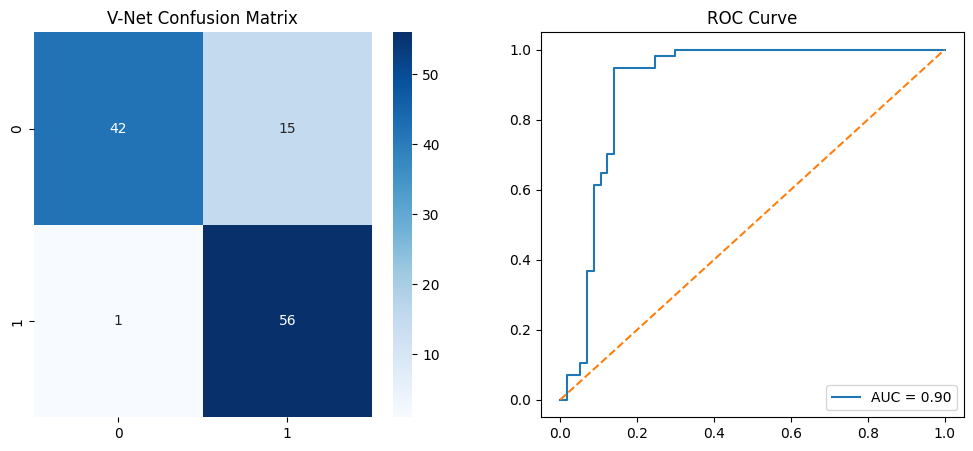

              precision    recall  f1-score   support

           0       0.98      0.74      0.84        57
           1       0.79      0.98      0.88        57

    accuracy                           0.86       114
   macro avg       0.88      0.86      0.86       114
weighted avg       0.88      0.86      0.86       114



In [14]:
import os
import gc
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import (
    Input, Conv3D, Conv3DTranspose, Add, PReLU,
    Dropout, Dense, GlobalAveragePooling3D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# --- CONFIG ---
PATCH_SIZE = 48   # smaller = stable
BATCH_SIZE = 1

BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# --- DATA GENERATOR ---
class PancreasVNetSeq(Sequence):
    def __init__(self, files, batch_size=BATCH_SIZE):
        self.files = files
        self.batch_size = batch_size
        self.samples = self.prepare()

    def prepare(self):
        samples = []
        for f in self.files:
            if f.startswith("._"):
                continue

            mask_path = os.path.join(MASK_DIR, f)
            if not os.path.exists(mask_path):
                continue

            mask = nib.load(mask_path).get_fdata()
            tumor = np.argwhere(mask == 2)

            if len(tumor) > 0:
                t = tumor[np.random.randint(len(tumor))]
                samples.append((f, t, 1))

                # random healthy
                while True:
                    pt = [
                        np.random.randint(0, mask.shape[0]),
                        np.random.randint(0, mask.shape[1]),
                        np.random.randint(0, mask.shape[2])
                    ]
                    if mask[tuple(pt)] == 0:
                        break
                samples.append((f, pt, 0))

        np.random.shuffle(samples)
        return samples

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx * self.batch_size:(idx + 1) * self.batch_size]
        X, y = [], []

        for f, center, label in batch:
            img = nib.load(os.path.join(IMAGE_DIR, f)).get_fdata()

            z, yc, x = [int(c) for c in center]
            ps = PATCH_SIZE // 2

            z_s, y_s, x_s = max(0, z-ps), max(0, yc-ps), max(0, x-ps)
            patch = img[z_s:z_s+PATCH_SIZE, y_s:y_s+PATCH_SIZE, x_s:x_s+PATCH_SIZE]

            if patch.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
                patch = np.pad(patch,
                               [(0, PATCH_SIZE-s) for s in patch.shape],
                               mode='constant')

            patch = np.clip(patch, -100, 200)
            patch = (patch + 100) / 300.0

            X.append(patch[..., np.newaxis])
            y.append(label)

        return np.array(X), np.array(y)

# --- V-NET BLOCK ---
def residual_block(x, filters):
    shortcut = Conv3D(filters, 1, padding='same')(x)  # FIX

    x = Conv3D(filters, 5, padding='same')(x)
    x = PReLU()(x)
    x = Conv3D(filters, 5, padding='same')(x)
    x = PReLU()(x)

    return Add()([x, shortcut])

# --- MODEL ---
def build_vnet():
    inputs = Input((PATCH_SIZE, PATCH_SIZE, PATCH_SIZE, 1))

    # Encoder
    c1 = Conv3D(16, 5, padding='same')(inputs)
    c1 = PReLU()(c1)
    r1 = residual_block(c1, 16)

    d1 = Conv3D(32, 2, strides=2, padding='same')(r1)
    d1 = PReLU()(d1)

    r2 = residual_block(d1, 32)

    d2 = Conv3D(64, 2, strides=2, padding='same')(r2)
    d2 = PReLU()(d2)

    # Bridge
    b = residual_block(d2, 64)

    # Decoder
    u2 = Conv3DTranspose(32, 2, strides=2, padding='same')(b)
    u2 = Add()([u2, r2])
    r3 = residual_block(u2, 32)

    u1 = Conv3DTranspose(16, 2, strides=2, padding='same')(r3)
    u1 = Add()([u1, r1])
    r4 = residual_block(u1, 16)

    # Classifier
    gap = GlobalAveragePooling3D()(r4)
    x = Dense(64, activation='relu')(gap)
    x = Dropout(0.4)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, output)
    model.compile(
        optimizer=Adam(5e-5),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

# --- EXECUTION ---
all_files = sorted([
    f for f in os.listdir(IMAGE_DIR)
    if (f.endswith(".nii") or f.endswith(".nii.gz"))
    and not f.startswith(".")
])

print("Total files:", len(all_files))

train_f, test_f = train_test_split(all_files, test_size=0.2, random_state=42)

train_seq = PancreasVNetSeq(train_f)
test_seq = PancreasVNetSeq(test_f)

model = build_vnet()

print("\nTraining V-Net...")
model.fit(train_seq, validation_data=test_seq, epochs=5)

# --- EVALUATION ---
y_true, y_probs = [], []

for i in range(len(test_seq)):
    xb, yb = test_seq[i]
    preds = model.predict(xb, verbose=0)
    y_true.extend(yb)
    y_probs.extend(preds.flatten())
    gc.collect()

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# Metrics
cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_probs)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("V-Net Confusion Matrix")

plt.subplot(1,2,2)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")

plt.show()

print(classification_report(y_true, y_pred))